In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
# ==========================================
# DAY 1 - SUPERVISED LEARNING
# Student Performance Prediction
# ==========================================

# 1. Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# 2. Create Sample Dataset

data = {
    "Study_Hours": [
        1,2,3,4,5,6,7,8,9,10,
        1,2,3,4,5,6,7,8,9,10,
        2,3,4,5,6,7,8,9,10,11
    ],

    "Attendance": [
        50,55,60,62,65,70,72,75,80,85,
        48,52,58,63,67,69,74,78,82,88,
        54,61,64,68,71,76,79,84,87,92
    ],

    "Assignments_Completed": [
        2,3,4,5,5,6,6,7,8,9,
        1,3,4,5,6,6,7,8,9,10,
        3,4,5,6,7,7,8,9,10,10
    ],

    "Pass": [
        0,0,0,0,1,1,1,1,1,1,
        0,0,0,1,1,1,1,1,1,1,
        0,0,1,1,1,1,1,1,1,1
    ]
}

df = pd.DataFrame(data)

df.head()

,Study_Hours,Attendance,Assignments_Completed,Pass
0,1,50,2,0
1,2,55,3,0
2,3,60,4,0
3,4,62,5,0
4,5,65,5,1


In [4]:
# 3. Dataset Information

print("Dataset Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (30, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Study_Hours            30 non-null     int64
 1   Attendance             30 non-null     int64
 2   Assignments_Completed  30 non-null     int64
 3   Pass                   30 non-null     int64
dtypes: int64(4)
memory usage: 1.1 KB
None

Statistical Summary:


,Study_Hours,Attendance,Assignments_Completed,Pass
count,30.000000,30.000000,30.000000,30.000000
mean,5.833333,69.633333,6.100000,0.700000
std,2.960467,12.015746,2.454412,0.466092
min,1.000000,48.000000,1.000000,0.000000
25%,3.250000,61.250000,4.250000,0.000000
50%,6.000000,69.500000,6.000000,1.000000
75%,8.000000,78.750000,8.000000,1.000000
max,11.000000,92.000000,10.000000,1.000000


In [5]:
# 4. Missing Values

print(df.isnull().sum())

Study_Hours              0
Attendance               0
Assignments_Completed    0
Pass                     0
dtype: int64


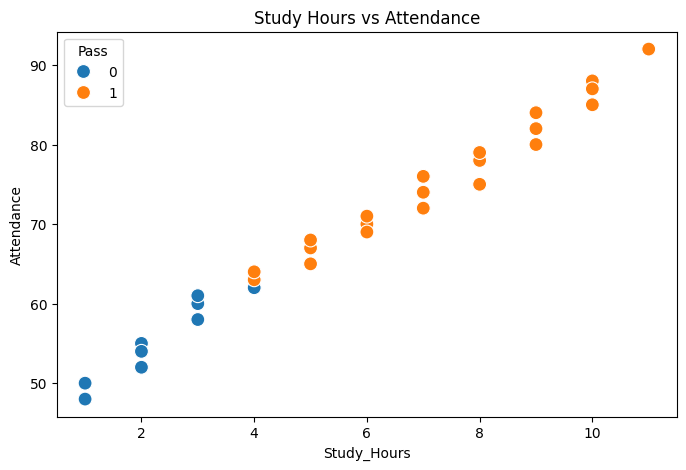

In [6]:
# 5. Visualization

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Attendance",
    hue="Pass",
    s=100
)

plt.title("Study Hours vs Attendance")
plt.show()

In [7]:
# 6. Feature Selection

X = df[
    [
        "Study_Hours",
        "Attendance",
        "Assignments_Completed"
    ]
]

y = df["Pass"]

print("Features:")
display(X.head())

print("Target:")
display(y.head())

Features:


,Study_Hours,Attendance,Assignments_Completed
0,1,50,2
1,2,55,3
2,3,60,4
3,4,62,5
4,5,65,5


Target:


,Pass
0,0
1,0
2,0
3,0
4,1


In [8]:
# 7. Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (24, 3)
Testing Data: (6, 3)


In [9]:
# 8. Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [10]:
# 9. Train Model

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [11]:
# 10. Prediction

y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
[1 1 1 1 0 1]


In [12]:
# 11. Model Evaluation

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 83.33 %


In [13]:
# 12. Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6



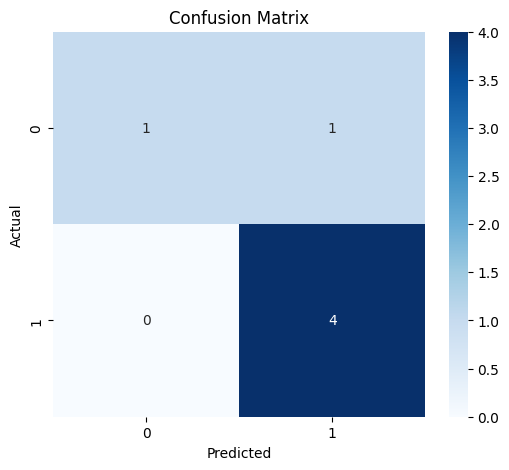

In [14]:
# 13. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [15]:
# 14. Predict New Student

new_student = pd.DataFrame({
    "Study_Hours": [7],
    "Attendance": [80],
    "Assignments_Completed": [8]
})

new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)

if prediction[0] == 1:
    print("Prediction: PASS")
else:
    print("Prediction: FAIL")

Prediction: PASS
